In [27]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [28]:
from sklearn.datasets import load_iris

X,y=load_iris(return_X_y=True)

In [29]:
df=pd.DataFrame(X,columns=load_iris().feature_names)

In [30]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [31]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

X_scaled=scaler.fit_transform(X)

In [32]:
X_scaled[:10]

array([[-0.90068117,  1.01900435, -1.34022653, -1.3154443 ],
       [-1.14301691, -0.13197948, -1.34022653, -1.3154443 ],
       [-1.38535265,  0.32841405, -1.39706395, -1.3154443 ],
       [-1.50652052,  0.09821729, -1.2833891 , -1.3154443 ],
       [-1.02184904,  1.24920112, -1.34022653, -1.3154443 ],
       [-0.53717756,  1.93979142, -1.16971425, -1.05217993],
       [-1.50652052,  0.78880759, -1.34022653, -1.18381211],
       [-1.02184904,  0.78880759, -1.2833891 , -1.3154443 ],
       [-1.74885626, -0.36217625, -1.34022653, -1.3154443 ],
       [-1.14301691,  0.09821729, -1.2833891 , -1.44707648]])

In [33]:
from sklearn.decomposition import PCA

model=PCA(n_components=2)
model.fit(X_scaled)

PCA(n_components=2)

In [34]:
X_scaled

array([[-9.00681170e-01,  1.01900435e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00, -1.31979479e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.38535265e+00,  3.28414053e-01, -1.39706395e+00,
        -1.31544430e+00],
       [-1.50652052e+00,  9.82172869e-02, -1.28338910e+00,
        -1.31544430e+00],
       [-1.02184904e+00,  1.24920112e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-5.37177559e-01,  1.93979142e+00, -1.16971425e+00,
        -1.05217993e+00],
       [-1.50652052e+00,  7.88807586e-01, -1.34022653e+00,
        -1.18381211e+00],
       [-1.02184904e+00,  7.88807586e-01, -1.28338910e+00,
        -1.31544430e+00],
       [-1.74885626e+00, -3.62176246e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00,  9.82172869e-02, -1.28338910e+00,
        -1.44707648e+00],
       [-5.37177559e-01,  1.47939788e+00, -1.28338910e+00,
        -1.31544430e+00],
       [-1.26418478e+00,  7.88807586e-01, -1.22655167e+00,
      

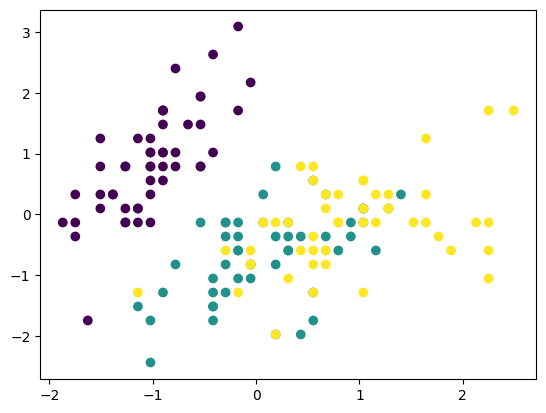

In [35]:
plt.scatter(X_scaled[:,0],X_scaled[:,1],c=y)


Text(0, 0.5, 'Euclidean Distance')

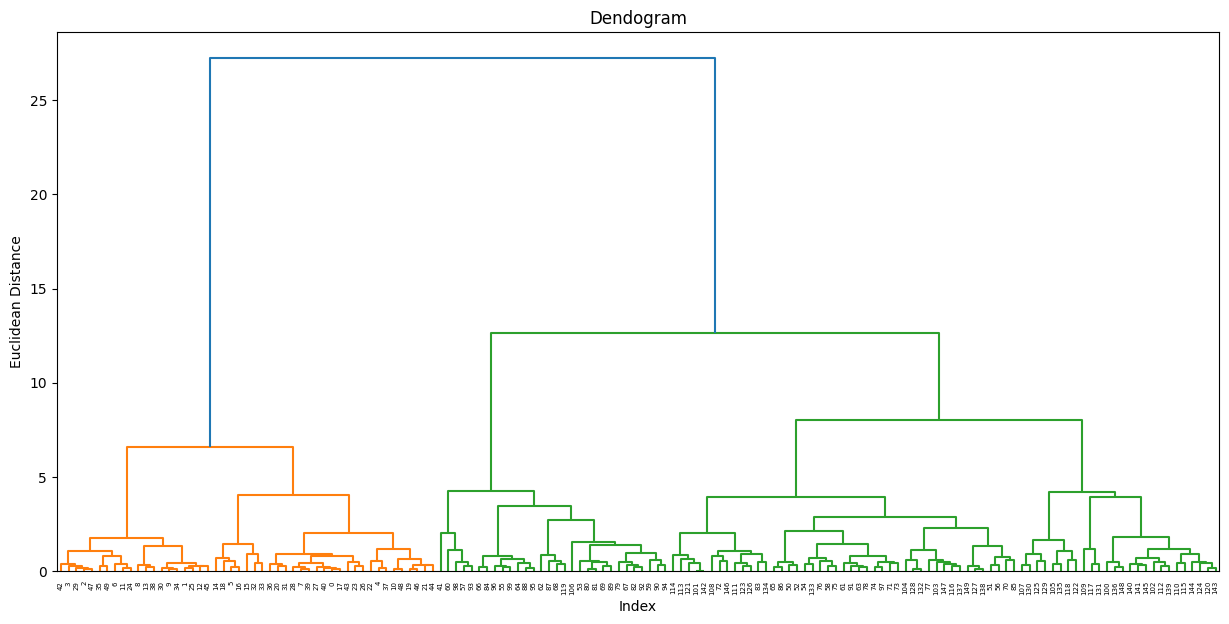

In [44]:
import scipy.cluster.hierarchy as sc
plt.figure(figsize=(15,7))
sc.dendrogram(sc.linkage(X_scaled,metric="euclidean", method="ward"))
plt.title("Dendogram")
plt.xlabel("Index")
plt.ylabel("Euclidean Distance")

In [42]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

coeff=[]
for i in range(2,11):
  algo=AgglomerativeClustering(n_clusters=i,metric="euclidean",linkage = "ward")
  algo.fit(X_scaled)
  score=silhouette_score(X_scaled,algo.labels_)
  coeff.append(score)

coeff

[0.5770346019475988,
 0.4466890410285909,
 0.4006363159855973,
 0.33058726295230545,
 0.31485480100512825,
 0.316969830299128,
 0.310946529007258,
 0.31143422475471655,
 0.3161120375980681]

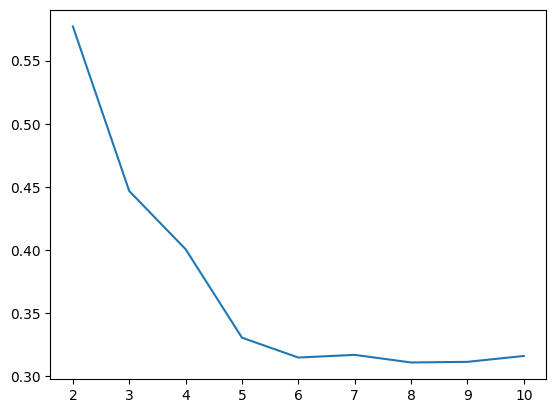

In [43]:
plt.plot(range(2,11), coeff)

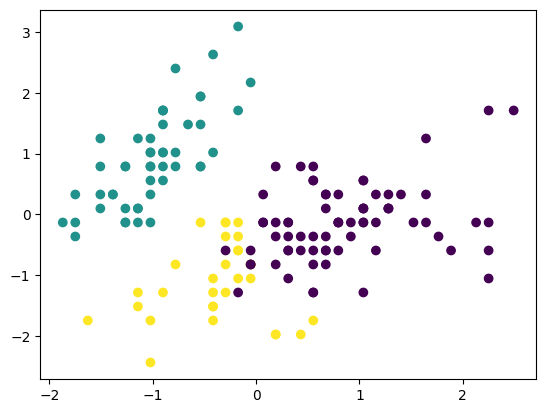

In [47]:
algo=AgglomerativeClustering(n_clusters=3,metric="euclidean",linkage = "ward")
algo.fit(X_scaled)

plt.scatter(X_scaled[:,0],X_scaled[:,1],c=algo.labels_)